In [33]:
import pandas as pd
import numpy as np
import os


xlsx_path = '/Users/bass/Desktop/HanwenLin/AD_DECODE_data3.xlsx'
df = pd.read_excel(xlsx_path)

df = df[(df['MRI_Exam'] != '0') & (df['MRI_Exam'] != '4491')& (df['MRI_Exam'] != '3866')]
df = df.dropna(subset = ['MRI_Exam'])

fa_dict = {}

# 
base_dir = '/Volumes/newJetStor/newJetStor/paros/paros_WORK/hanwen/ad_decode_test/output/input_columns'

for exam in df['MRI_Exam']:
    try:
        exam_int = int(float(exam)) 
        exam_str = str(exam_int).zfill(4)  
        subject_id = f"{exam_str}"
        
        fa_path = os.path.join(base_dir, f"S0{subject_id}_columns_1mm", f"S0{subject_id}_fa.csv")
        
        if os.path.exists(fa_path):
            fa_values = np.loadtxt(fa_path, delimiter=',')
            fa_dict[subject_id] = fa_values
        else:
            print(f"File not found: {fa_path}")
    except Exception as e:
        print(f"Error with MRI_Exam = {exam}: {e}")


File not found: /Volumes/newJetStor/newJetStor/paros/paros_WORK/hanwen/ad_decode_test/output/input_columns/S02469_columns_1mm/S02469_fa.csv
File not found: /Volumes/newJetStor/newJetStor/paros/paros_WORK/hanwen/ad_decode_test/output/input_columns/S02289_columns_1mm/S02289_fa.csv
File not found: /Volumes/newJetStor/newJetStor/paros/paros_WORK/hanwen/ad_decode_test/output/input_columns/S02266_columns_1mm/S02266_fa.csv
File not found: /Volumes/newJetStor/newJetStor/paros/paros_WORK/hanwen/ad_decode_test/output/input_columns/S02686_columns_1mm/S02686_fa.csv
File not found: /Volumes/newJetStor/newJetStor/paros/paros_WORK/hanwen/ad_decode_test/output/input_columns/S02812_columns_1mm/S02812_fa.csv
File not found: /Volumes/newJetStor/newJetStor/paros/paros_WORK/hanwen/ad_decode_test/output/input_columns/S02842_columns_1mm/S02842_fa.csv
File not found: /Volumes/newJetStor/newJetStor/paros/paros_WORK/hanwen/ad_decode_test/output/input_columns/S02224_columns_1mm/S02224_fa.csv
File not found: /Vol

In [34]:
del fa_dict['3394']
del fa_dict['3048']
del fa_dict['4491']

In [35]:
fa_dict.keys()

dict_keys(['2110', '2363', '2373', '2386', '2390', '2231', '2402', '2410', '2421', '1912', '2424', '2446', '2451', '2485', '2473', '2491', '2506', '2524', '2535', '2654', '2666', '2670', '2690', '2695', '2715', '2720', '2737', '2753', '2227', '2765', '2771', '2781', '2802', '2804', '2813', '2817', '2840', '2877', '2898', '2926', '2938', '2939', '2954', '2967', '2987', '3010', '2320', '3017', '3028', '3033', '3034', '3045', '3069', '3225', '3265', '3293', '3308', '3343', '3350', '3378', '3391', '3847', '3866', '3889', '3890', '3896', '0775', '4493', '1412', '4526', '1470', '1619'])

In [36]:
region_list = ['bankssts',
'caudalanteriorcingulate',
'caudalmiddlefrontal',
'cuneus',
'entorhinal',
'fusiform',
'inferiorparietal',
'inferiortemporal',
'isthmuscingulate',
'lateraloccipital',
'lateralorbitofrontal',
'lingual',
'medialorbitofrontal',
'middletemporal',
'parahippocampal',
'paracentral',
'parsopercularis',
'parsorbitalis',
'parstriangularis',
'pericalcarine',
'postcentral',
'posteriorcingulate',
'precentral',
'precuneus',
'rostralanteriorcingulate',
'rostralmiddlefrontal',
'superiorfrontal',
'superiorparietal',
'superiortemporal',
'supramarginal',
'frontalpole',
'temporalpole',
'transversetemporal',
'insula'
]

# List of brain hemispheres
hemis = ['lh', 'rh', 'rl']

# Dictionary to store data for all subjects
fa_dict2 = {}

subject_ids = fa_dict.keys()  # You can replace this with your own list

# Parent directory where the data is stored, e.g., "input_columns"
base_dir = '/Volumes/newJetStor/newJetStor/paros/paros_WORK/hanwen/ad_decode_test/output/input_columns'

for subj_id in subject_ids:
    # Construct folder name, e.g., "S001412_columns"
    folder_name = f"S0{subj_id}_columns_1mm"
    subject_folder = os.path.join(base_dir, folder_name)
    
    if not os.path.isdir(subject_folder):
        print(f"Folder not found: {subject_folder}")
        continue

    # List to collect FA values from all regions for this subject
    region_values_list = []

    for hemi in hemis:
        for region in region_list:
            # File name format: S01412_lh_BA1_exvivo_md.csv
            csv_name = f"S0{subj_id}_{hemi}_{region}_md.csv"
            csv_path = os.path.join(subject_folder, csv_name)
            
            if os.path.exists(csv_path):
                # Read 21 FA values
                values = np.loadtxt(csv_path, delimiter=',')
                region_values_list.append(values)
            else:
                # This region or hemisphere might not exist, or might be empty after thresholding; this is just a warning
                # You may choose not to print this
                print(f"File not found: {csv_path}")

    # If region_values_list is not empty, concatenate all the values
    if region_values_list:
        # Each item in region_values_list has shape = (21,)
        # After concatenation it becomes a 1D vector of length = 21 * number of valid files
        region_values_concat = np.concatenate(region_values_list)
        # Store into fa_dict2 with subject_id as key
        fa_dict2[subj_id] = region_values_concat
    else:
        print(f"No region files found for subject {subj_id}")

# Check results
for k, v in fa_dict2.items():
    print(f"Subject {k}: shape = {v.shape}")


Subject 2110: shape = (2142,)
Subject 2363: shape = (2142,)
Subject 2373: shape = (2142,)
Subject 2386: shape = (2142,)
Subject 2390: shape = (2142,)
Subject 2231: shape = (2142,)
Subject 2402: shape = (2142,)
Subject 2410: shape = (2142,)
Subject 2421: shape = (2142,)
Subject 1912: shape = (2142,)
Subject 2424: shape = (2142,)
Subject 2446: shape = (2142,)
Subject 2451: shape = (2142,)
Subject 2485: shape = (2142,)
Subject 2473: shape = (2142,)
Subject 2491: shape = (2142,)
Subject 2506: shape = (2142,)
Subject 2524: shape = (2142,)
Subject 2535: shape = (2142,)
Subject 2654: shape = (2142,)
Subject 2666: shape = (2142,)
Subject 2670: shape = (2142,)
Subject 2690: shape = (2142,)
Subject 2695: shape = (2142,)
Subject 2715: shape = (2142,)
Subject 2720: shape = (2142,)
Subject 2737: shape = (2142,)
Subject 2753: shape = (2142,)
Subject 2227: shape = (2142,)
Subject 2765: shape = (2142,)
Subject 2771: shape = (2142,)
Subject 2781: shape = (2142,)
Subject 2802: shape = (2142,)
Subject 28

In [37]:
len(fa_dict2)

72

In [31]:
# del fa_dict2['4493']
# del fa_dict2['3866']

In [39]:
# ---------------------------
# 1. Read the Excel file and process the MRI_Exam column
# ---------------------------

# Drop rows with missing MRI_Exam
df = df.dropna(subset=['MRI_Exam'])

# Generate subject_id from MRI_Exam, convert to integer, then pad with zeros to 4 digits
df['subject_id'] = df['MRI_Exam'].astype(float).astype(int).astype(str).str.zfill(4)

# Set subject_id as the index for easier matching later
df = df.set_index('subject_id')

# ---------------------------
# 2. Drop unnecessary columns: 'Family', 'Fam_Num', 'Subject'
# ---------------------------
df = df.drop(columns=['Family', 'Fam_Num', 'Subject'])

# ---------------------------
# 3. One-hot encode categorical variables
# ---------------------------
categorical_cols = ['sex', 'genotype', 'Risk', 'ethnicity']
one_hot = pd.get_dummies(df[categorical_cols], prefix=categorical_cols)

# ---------------------------
# 4. Extract numerical features and isolate 'age' as y (only keep subjects that exist in fa_dict)
# ---------------------------
y = df['age']
# Keep only indices in y that exist in fa_dict
y = y[y.index.isin(fa_dict.keys())]

# Numerical features: drop categorical variables, 'age', and 'MRI_Exam' (no longer needed)
numerical = df.drop(columns=categorical_cols + ['age', 'MRI_Exam'])

# Combine numerical features and one-hot encoded features
bio_features = pd.concat([numerical, one_hot], axis=1)

# ---------------------------
# 5. Combine fa_dict with bio_features to create the full feature vector
# ---------------------------
combined_features = []
subject_ids = []

for subject_id, fa_vector in fa_dict2.items():
    if subject_id in bio_features.index:
        # Get the subject's bio features as a float array
        bio_vector = bio_features.loc[subject_id].values.astype(float)
        # Concatenate FA vector and bio features
        full_vector = np.concatenate([fa_vector, bio_vector])
        combined_features.append(full_vector)
        subject_ids.append(subject_id)
    else:
        print(f"Warning: Subject {subject_id} not found in bio features!")

# Build the final DataFrame, where each row corresponds to a subject's full feature vector
final_features_df = pd.DataFrame(combined_features, index=subject_ids)

# Make sure y aligns with the index of final_features_df
final_y = y.loc[final_features_df.index]

# Display the first few rows
print(final_features_df.head())
print(final_y.head())


          0         1         2         3         4         5         6     \
2110  0.740473  0.743901  0.747203  0.750823  0.754844  0.759560  0.764993   
2363  0.717224  0.719654  0.722332  0.725400  0.729118  0.733747  0.739800   
2373  0.687904  0.696766  0.706258  0.716408  0.727266  0.738961  0.751476   
2386  0.685329  0.686147  0.687075  0.688175  0.689635  0.691357  0.693803   
2390  0.673767  0.673092  0.672933  0.673366  0.674603  0.676935  0.680575   

          7         8         9     ...  2185  2186  2187  2188  2189  2190  \
2110  0.771259  0.778685  0.787409  ...   0.0   0.0   0.0   0.0   0.0   0.0   
2363  0.747745  0.758181  0.771482  ...   0.0   0.0   0.0   0.0   1.0   0.0   
2373  0.764958  0.779438  0.794783  ...   0.0   0.0   1.0   0.0   0.0   0.0   
2386  0.697336  0.702295  0.708221  ...   0.0   0.0   1.0   0.0   0.0   0.0   
2390  0.685539  0.692170  0.700391  ...   1.0   0.0   1.0   0.0   0.0   0.0   

      2191  2192  2193  2194  
2110   1.0   0.0   0.0   

In [40]:
final_features_df.head()

,0,1,2,3,4,5,6,7,8,9,...,2185,2186,2187,2188,2189,2190,2191,2192,2193,2194
2110,0.740473,0.743901,0.747203,0.750823,0.754844,0.759560,0.764993,0.771259,0.778685,0.787409,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2363,0.717224,0.719654,0.722332,0.725400,0.729118,0.733747,0.739800,0.747745,0.758181,0.771482,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2373,0.687904,0.696766,0.706258,0.716408,0.727266,0.738961,0.751476,0.764958,0.779438,0.794783,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2386,0.685329,0.686147,0.687075,0.688175,0.689635,0.691357,0.693803,0.697336,0.702295,0.708221,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2390,0.673767,0.673092,0.672933,0.673366,0.674603,0.676935,0.680575,0.685539,0.692170,0.700391,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [41]:
# Find NaN in final_features_df
nan_indices = final_features_df.isnull().any(axis=1)
nan_positions = nan_indices.loc[nan_indices.index].values
print(nan_positions)

[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False]


## Method1: PCA + LASSO

In [43]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def perform_pca_and_plot(X, n_components=35):
    """
    Perform PCA on the given dataset, plot variance explained by each component, 
    and compute the cumulative variance explained.

    Args:
        X (np.ndarray): The input data matrix.
        n_components (int): Number of principal components to consider.

    Returns:
        tuple: Transformed data after PCA, explained variance ratio, and cumulative variance.
    """
    # Standardize the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Perform PCA
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)

    # Calculate the explained variance ratio
    explained_variance_ratio = pca.explained_variance_ratio_

    # Compute the cumulative variance explained
    cumulative_variance = np.cumsum(explained_variance_ratio)

    # Plot the explained variance and cumulative variance
    plt.figure(figsize=(10, 6))
    plt.bar(range(1, n_components + 1), explained_variance_ratio * 100, alpha=0.7, label='Variance Explained (%)')
    plt.plot(range(1, n_components + 1), cumulative_variance * 100, marker='o', color='r', label='Cumulative Variance (%)')
    plt.xlabel('Principal Component')
    plt.ylabel('Variance Explained (%)')
    plt.title(f'Variance Explained by Each of the First {n_components} Principal Components')
    plt.legend()
    plt.show()

    # Print the cumulative variance explained
    print(f"Cumulative variance explained by the first {n_components} principal components: {cumulative_variance[-1] * 100:.2f}%")

    return X_pca, explained_variance_ratio, cumulative_variance



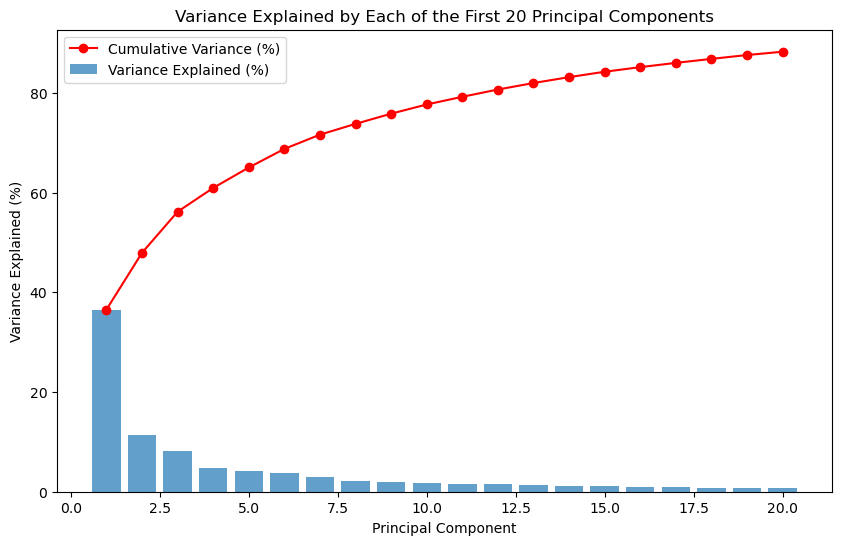

Cumulative variance explained by the first 20 principal components: 88.24%


In [51]:
X_pca, explained_variance_ratio, cumulative_variance = perform_pca_and_plot(final_features_df, n_components=20)

In [52]:
X_pca.shape

(72, 20)

In [54]:
from sklearn.linear_model import Lasso, LassoCV
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import scipy.stats as stats

def lasso_cross_validation(features, target, risk_series=None, n_splits=5, cv_inner=5, random_state=123):
    """
    Perform nested cross-validation using Lasso regression.
    First, LassoCV is used to find the optimal lambda (alpha),
    then KFold is used to evaluate model performance.
    If risk_series is provided, MAE is also computed for each risk group separately.

    Parameters:
        features (np.ndarray or pd.DataFrame): Feature matrix. If a numpy array is provided,
                                               it will be converted to a DataFrame using the index of the target.
        target (pd.Series): Target variable. Must be a Pandas Series with an index.
        risk_series (pd.Series, optional): Risk variable (risk_for_ad), with the following value mapping:
            - {0,1} are treated as 0 (low risk)
            - {2,3} are treated as 1 (high risk)
        n_splits (int): Number of folds for outer KFold cross-validation.
        cv_inner (int): Number of folds for inner cross-validation (used in LassoCV to select lambda).
        random_state (int): Random seed.

    Returns:
        dict: Dictionary containing the optimal lambda, overall MAE, overall Pearson correlation,
              and mean MAEs for risk group 0 and risk group 1 (if risk_series is provided).
    """
    # If features is not a DataFrame, convert it using the index of the target
    if not isinstance(features, pd.DataFrame):
        if not hasattr(target, "index"):
            raise ValueError("target must be a Pandas Series with an index to align with features")
        features = pd.DataFrame(features, index=target.index)
    
    # Align indices if risk_series is provided (use the intersection of all indices)
    if risk_series is not None:
        common_index = features.index.intersection(target.index).intersection(risk_series.index)
        features = features.loc[common_index].sort_index()
        target = target.loc[common_index].sort_index()
        risk_series = risk_series.loc[common_index].sort_index()
    else:
        common_index = features.index.intersection(target.index)
        features = features.loc[common_index].sort_index()
        target = target.loc[common_index].sort_index()
    
    # Convert to numpy arrays
    X = features.values
    y = target.values

    # Step 1: Use LassoCV with inner cross-validation to select the best lambda
    lasso_cv = LassoCV(cv=cv_inner, random_state=random_state).fit(X, y)
    best_lambda = lasso_cv.alpha_

    # Step 2: Outer cross-validation to evaluate model performance
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    mae_scores = []
    pearson_corr_scores = []
    
    # If risk_series is provided, track MAE for each risk group
    mae_risk0 = []
    mae_risk1 = []
    y_pred_risk0 = []
    y_pred_risk1 = []
    y_true_risk0 = []
    y_true_risk1 = []
    
    # kf.split returns row indices (corresponding to rows in X)
    i = 0
    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        # If risk_series is provided, get the risk values for the test set
        if risk_series is not None:
            risk_test = risk_series.iloc[test_index].values
            # Map risk values: {0,1} -> 0; {2,3} -> 1
            risk_binary = np.where(np.isin(risk_test, [2, 3]), 1, 0)
        
        # Train the Lasso model with the selected lambda
        lasso = Lasso(alpha=best_lambda, random_state=random_state)
        lasso.fit(X_train, y_train)
        y_pred = lasso.predict(X_test)
        
        # Compute overall MAE
        mae = mean_absolute_error(y_test, y_pred)
        mae_scores.append(mae)
        
        # Compute overall Pearson correlation
        pearson_corr, _ = stats.pearsonr(y_test, y_pred)
        pearson_corr_scores.append(pearson_corr)
        
        # If risk_series is provided, compute MAE separately for each risk group
        if risk_series is not None:
            mask0 = (risk_binary == 0)
            mask1 = (risk_binary == 1)
            
            if np.any(mask0):
                mae0 = mean_absolute_error(y_test[mask0], y_pred[mask0])
                mae_risk0.append(mae0)
                y_pred_risk0.append(y_pred[mask0])
                y_true_risk0.append(y_test[mask0])
            if np.any(mask1):
                mae1 = mean_absolute_error(y_test[mask1], y_pred[mask1])
                mae_risk1.append(mae1)
                y_pred_risk1.append(y_pred[mask1])
                y_true_risk1.append(y_test[mask1])
        i = i + 1
    
    mean_mae = np.mean(mae_scores)
    mean_pearson_corr = np.mean(pearson_corr_scores)
    
    result = {
        "best_lambda": best_lambda,
        "mean_mae": mean_mae,
        "mean_pearson_corr": mean_pearson_corr,
        "predicted_y_risk0": y_pred_risk0,
        "predicted_y_risk1": y_pred_risk1,
        "True_y_risk0": y_true_risk0,
        "True_y_risk1": y_true_risk1
    }
    if risk_series is not None:
        result["mean_mae_risk0"] = np.mean(mae_risk0) if mae_risk0 else np.nan
        result["mean_mae_risk1"] = np.mean(mae_risk1) if mae_risk1 else np.nan
    
    return result


risk = df['risk_for_ad']
risk = risk[risk.index.isin(fa_dict.keys())]
risk = risk.loc[final_features_df.index]

results = lasso_cross_validation(X_pca, final_y, risk_series=risk, n_splits=5, cv_inner=5, random_state=123)
print("Best Lambda (alpha):", results['best_lambda'])
print("Overall Mean MAE:", results['mean_mae'])
print("Overall Mean Pearson Correlation:", results['mean_pearson_corr'])
if "mean_mae_risk0" in results and "mean_mae_risk1" in results:
    print("Mean MAE (risk=0,1 group):", results['mean_mae_risk0'])
    print("Mean MAE (risk=2,3 group):", results['mean_mae_risk1'])

Best Lambda (alpha): 24.35573017169685
Overall Mean MAE: 8.71281879499696
Overall Mean Pearson Correlation: 0.7549673194835138
Mean MAE (risk=0,1 group): 8.667071695768076
Mean MAE (risk=2,3 group): 9.069660202844545


/var/folders/zm/9tdmn_3x1qdczqlys3lvt18m0000gw/T/ipykernel_24798/2182365377.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot(results['True_y_risk0'][i], results['True_y_risk0'][i], 'k--', color='r')


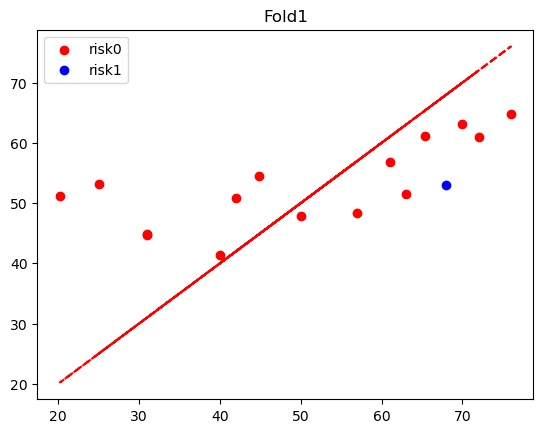

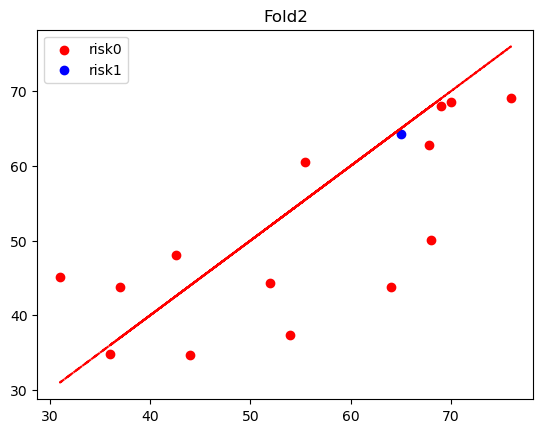

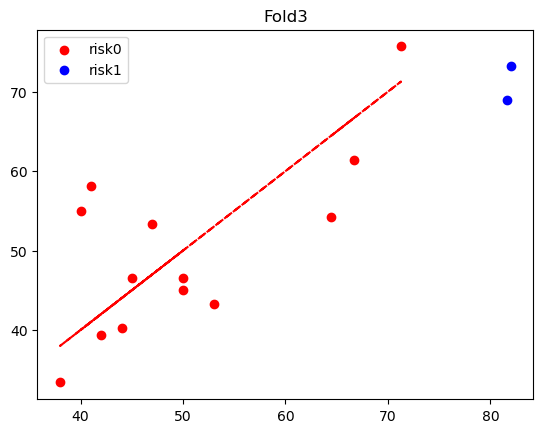

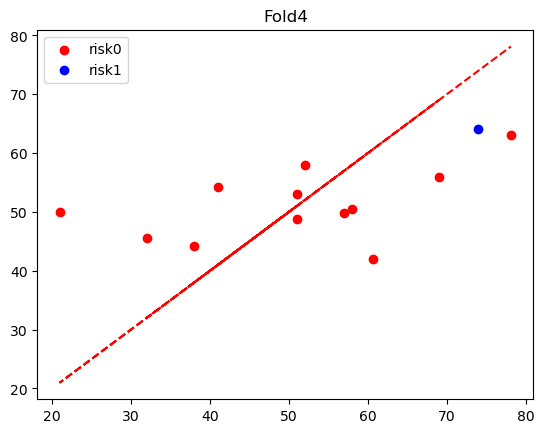

In [55]:
# Plot the predicted_y versus true_y
for i in range(4):
    # For fold i
    plt.scatter(results['True_y_risk0'][i], results['predicted_y_risk0'][i], label='risk0', color='r')
    plt.scatter(results['True_y_risk1'][i], results['predicted_y_risk1'][i], label='risk1', color='b')
    plt.plot(results['True_y_risk0'][i], results['True_y_risk0'][i], 'k--', color='r')
    plt.title('Fold' + str(i+1))
    plt.legend()
    plt.show()


## Method 2: PLSRegression

In [48]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import scipy.stats as stats

def pls_cross_validation_with_risk(
    df_features: pd.DataFrame,
    series_target: pd.Series,
    risk_series: pd.Series,
    n_splits: int = 5,
    cv_inner: int = 4,
    max_components: int = 20,
    random_state: int = 42
) -> dict:
    """
    Perform Partial Least Squares Regression (PLSRegression) using nested cross-validation,
    and compute MAE separately for each risk group.

    Assumes risk_for_ad has values:
        - {0, 1} are treated as risk group 0
        - {2, 3} are treated as risk group 1

    Parameters:
        df_features (pd.DataFrame): Feature matrix, indexed by subject_id or other unique identifier.
        series_target (pd.Series): Target variable (e.g., age), aligned with df_features.
        risk_series (pd.Series): Risk group labels, aligned with df_features.
        n_splits (int): Number of outer folds for cross-validation.
        cv_inner (int): Number of inner folds for selecting optimal number of components.
        max_components (int): Maximum number of components to consider.
        random_state (int): Random seed for reproducibility.

    Returns:
        dict: Dictionary containing:
            "best_n_components": Optimal number of PLS components
            "mean_mae": Overall average MAE from outer CV
            "mean_pearson_corr": Average Pearson correlation from outer CV
            "mean_mae_risk0": Average MAE for risk group 0
            "mean_mae_risk1": Average MAE for risk group 1
    """

    # 1. Align indices & convert to NumPy arrays
    common_index = df_features.index.intersection(series_target.index).intersection(risk_series.index)
    common_index = common_index.sort_values()

    X = df_features.loc[common_index].sort_index().values
    y = series_target.loc[common_index].sort_index().values
    risk_vals = risk_series.loc[common_index].sort_index().values

    # Map risk values to binary: {0,1} -> 0, {2,3} -> 1
    risk_binary = np.where(np.isin(risk_vals, [2, 3]), 1, 0)

    # 2. Inner CV: select best number of components
    inner_kf = KFold(n_splits=cv_inner, shuffle=True, random_state=random_state)
    candidate_mae = []

    for n_comp in range(1, max_components + 1):
        inner_mae_scores = []
        for train_idx, val_idx in inner_kf.split(X):
            X_train_inner, X_val = X[train_idx], X[val_idx]
            y_train_inner, y_val = y[train_idx], y[val_idx]

            pls = PLSRegression(n_components=n_comp)
            pls.fit(X_train_inner, y_train_inner)

            y_pred_val = pls.predict(X_val).ravel()
            mae_val = mean_absolute_error(y_val, y_pred_val)
            inner_mae_scores.append(mae_val)

        candidate_mae.append(np.mean(inner_mae_scores))

    best_n_components = np.argmin(candidate_mae) + 1

    # 3. Outer CV: evaluate overall and per-risk-group performance using best_n_components
    outer_kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    outer_mae_scores = []
    outer_pearson_corr = []

    # Additionally track MAEs for different risk groups
    outer_mae_risk0 = []
    outer_mae_risk1 = []

    for train_idx, test_idx in outer_kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        risk_test = risk_binary[test_idx]

        pls = PLSRegression(n_components=best_n_components)
        pls.fit(X_train, y_train)

        y_pred = pls.predict(X_test).ravel()

        # Overall MAE
        mae_outer = mean_absolute_error(y_test, y_pred)
        outer_mae_scores.append(mae_outer)

        # Overall Pearson correlation
        pearson_corr, _ = stats.pearsonr(y_test, y_pred)
        outer_pearson_corr.append(pearson_corr)

        # Group-wise MAE: risk0 vs. risk1
        mask_risk0 = (risk_test == 0)
        mask_risk1 = (risk_test == 1)

        # Only compute MAE for a group if it has samples
        if np.any(mask_risk0):
            mae_risk0 = mean_absolute_error(y_test[mask_risk0], y_pred[mask_risk0])
            outer_mae_risk0.append(mae_risk0)
        if np.any(mask_risk1):
            mae_risk1 = mean_absolute_error(y_test[mask_risk1], y_pred[mask_risk1])
            outer_mae_risk1.append(mae_risk1)

    mean_mae = np.mean(outer_mae_scores)
    mean_pearson_corr = np.mean(outer_pearson_corr)

    mean_mae_risk0 = np.mean(outer_mae_risk0) if len(outer_mae_risk0) > 0 else np.nan
    mean_mae_risk1 = np.mean(outer_mae_risk1) if len(outer_mae_risk1) > 0 else np.nan

    return {
        "best_n_components": best_n_components,
        "mean_mae": mean_mae,
        "mean_pearson_corr": mean_pearson_corr,
        "mean_mae_risk0": mean_mae_risk0,
        "mean_mae_risk1": mean_mae_risk1
    }


In [49]:
results = pls_cross_validation_with_risk(final_features_df, final_y, risk)
print("Best number of components:", results["best_n_components"])
print("Overall Mean MAE:", results["mean_mae"])
print("Overall Mean Pearson Correlation:", results["mean_pearson_corr"])
print("Mean MAE (risk=0 group):", results["mean_mae_risk0"])
print("Mean MAE (risk=1 group):", results["mean_mae_risk1"])


Best number of components: 2
Overall Mean MAE: 7.860792793990552
Overall Mean Pearson Correlation: 0.7665291333599149
Mean MAE (risk=0 group): 7.872821007632453
Mean MAE (risk=1 group): 8.016090098428842
